# NewsBot Intelligence System 2.0 — 02 Advanced Classification

## Goal
Compare the preserved midterm baseline to enhanced candidates and inspect confidence-aware outputs.

This notebook imports reusable project modules rather than duplicating implementation logic.

## Fit comparable models
A fixed seed and stratified holdout make the comparison reproducible.

In [1]:
from src.analysis.classifier import AdvancedNewsClassifier
from src.data_processing.data_validator import load_news_dataset
df = load_news_dataset()
classifier = AdvancedNewsClassifier().fit(df.full_text, df.category)
classifier.evaluation_results['model_comparison']

[{'model': 'Multinomial Naive Bayes (midterm baseline)',
  'accuracy': 0.7138888888888889,
  'macro_f1': 0.7118910656946621,
  'weighted_f1': 0.7118910656946622},
 {'model': 'Logistic Regression (enhanced)',
  'accuracy': 0.7083333333333334,
  'macro_f1': 0.7080949616417446,
  'weighted_f1': 0.7080949616417445},
 {'model': 'Calibrated Linear SVM (enhanced)',
  'accuracy': 0.7083333333333334,
  'macro_f1': 0.707099026541916,
  'weighted_f1': 0.707099026541916}]

## Held-out metrics and calibration
Macro F1 is appropriate for the balanced six-category sample; calibration is top-label ECE.

In [2]:
{key: classifier.evaluation_results[key] for key in ['selected_model','accuracy','macro_precision','macro_recall','macro_f1','weighted_f1','calibration']}

{'selected_model': 'Multinomial Naive Bayes (midterm baseline)',
 'accuracy': 0.7138888888888889,
 'macro_precision': 0.7209936430170055,
 'macro_recall': 0.7138888888888889,
 'macro_f1': 0.7118910656946621,
 'weighted_f1': 0.7118910656946622,
 'calibration': {'expected_calibration_error': 0.3748121538866589,
  'mean_confidence': 0.33907673500223,
  'top_label_accuracy': 0.7138888888888889,
  'interpretation': 'Top-label expected calibration error on the held-out split; lower is better.'}}

## Confidence and explainability
Explanations are only coefficient-based when the selected model is Logistic Regression.

In [3]:
example = 'A technology company introduced an artificial intelligence software tool for small businesses.'
classifier.predict_with_confidence(example), classifier.explain_prediction(example)

({'primary_category': 'TECH',
  'content_family': 'Technology',
  'confidence': 0.3879649768559903,
  'alternatives': [{'category': 'BUSINESS', 'confidence': 0.32233680767033657},
   {'category': 'WELLNESS', 'confidence': 0.09287607621719228}],
  'manual_review_recommended': True},
 {'primary_category': 'TECH',
  'content_family': 'Technology',
  'confidence': 0.3879649768559903,
  'alternatives': [{'category': 'BUSINESS', 'confidence': 0.32233680767033657},
   {'category': 'WELLNESS', 'confidence': 0.09287607621719228}],
  'manual_review_recommended': True,
  'top_features': [],
  'explanation_note': 'Feature coefficients are available for the logistic-regression model only.'})

## Visual evidence
Read the confusion matrix alongside classes with overlapping language.

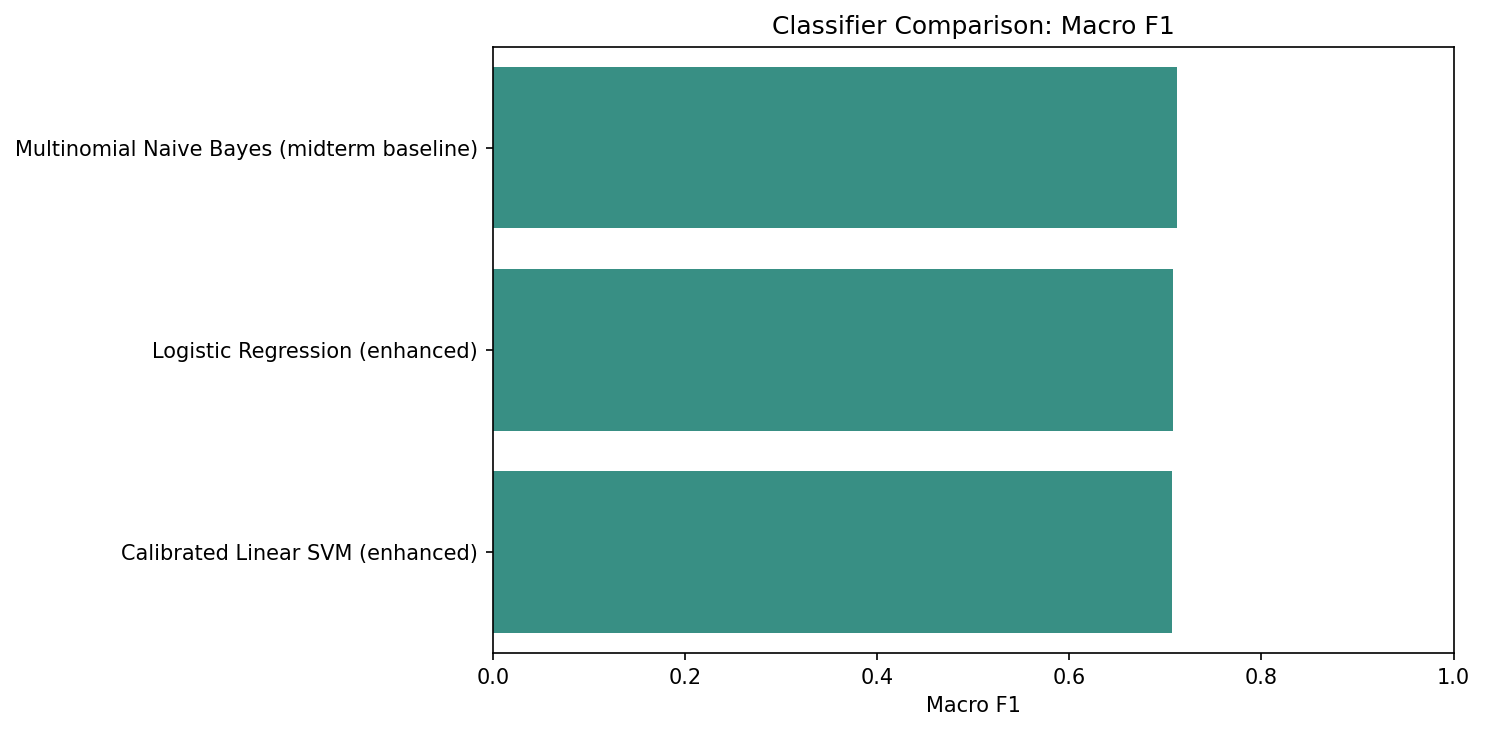

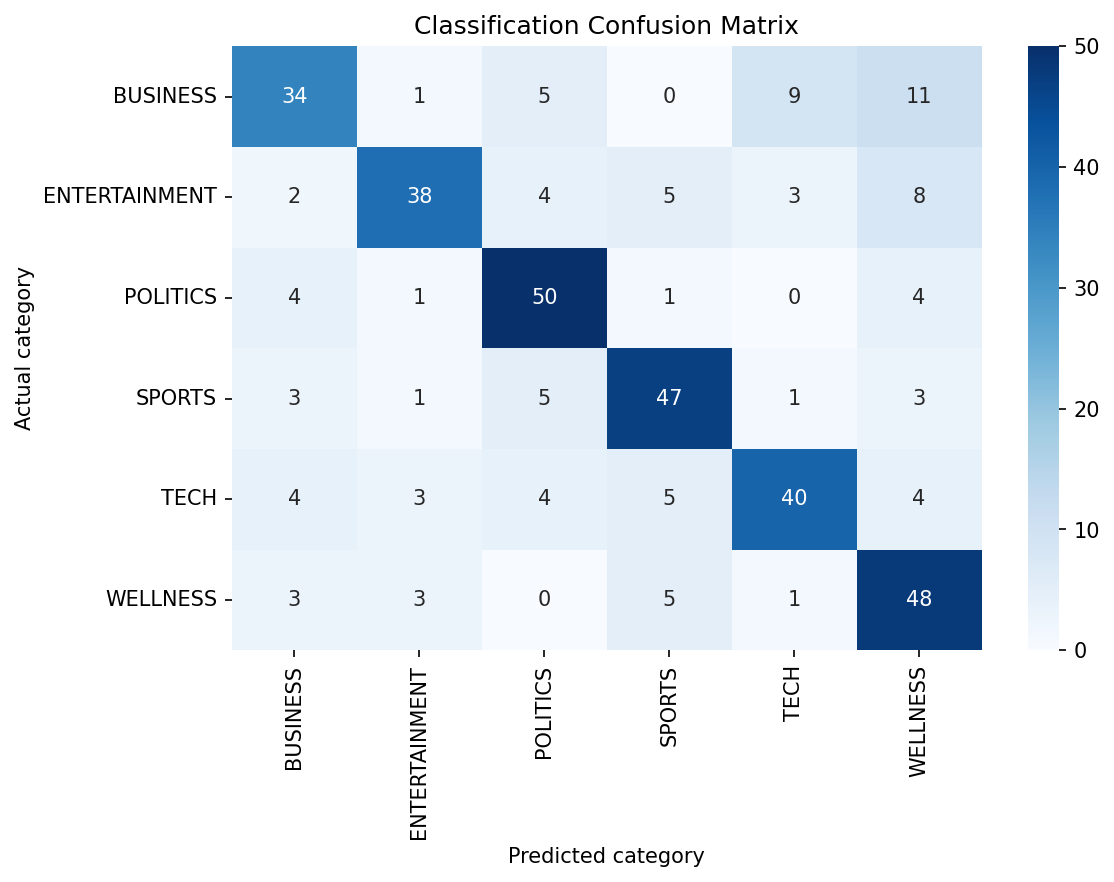

In [4]:
from IPython.display import Image, display
from pathlib import Path
figures = Path('data/results/figures')
display(Image(filename=str(figures / 'model_comparison.png')))
display(Image(filename=str(figures / 'classification_confusion_matrix.png')))

## Limitations and ethics
The source corpus is historical and predominantly English. Confidence is not truth; sentiment, topics, named entities, translation, summaries, and semantic similarity can be wrong. Entity co-occurrence is not a proven real-world relationship. Internal corpus corroboration is not independent fact-checking.